In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [43]:
df=pd.read_csv("WineQT.csv")

In [44]:
print (df.head())


   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  Id  
0      9.4        5   0  
1      9.8        5   1  
2      9

In [45]:
print(df.isnull())

      fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0             False             False        False           False      False   
1             False             False        False           False      False   
2             False             False        False           False      False   
3             False             False        False           False      False   
4             False             False        False           False      False   
...             ...               ...          ...             ...        ...   
1138          False             False        False           False      False   
1139          False             False        False           False      False   
1140          False             False        False           False      False   
1141          False             False        False           False      False   
1142          False             False        False           False      False   

      free sulfur dioxide  

In [46]:
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,0
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,1
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,2
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,3
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1138,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6,1592
1139,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6,1593
1140,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,1594
1141,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6,1595


In [47]:
##Correlation matrix

In [48]:
corr_matrix = df.corr()
print(corr_matrix)


                      fixed acidity  volatile acidity  citric acid  \
fixed acidity              1.000000         -0.250728     0.673157   
volatile acidity          -0.250728          1.000000    -0.544187   
citric acid                0.673157         -0.544187     1.000000   
residual sugar             0.171831         -0.005751     0.175815   
chlorides                  0.107889          0.056336     0.245312   
free sulfur dioxide       -0.164831         -0.001962    -0.057589   
total sulfur dioxide      -0.110628          0.077748     0.036871   
density                    0.681501          0.016512     0.375243   
pH                        -0.685163          0.221492    -0.546339   
sulphates                  0.174592         -0.276079     0.331232   
alcohol                   -0.075055         -0.203909     0.106250   
quality                    0.121970         -0.407394     0.240821   
Id                        -0.275826         -0.007892    -0.139011   

                   


Correlation with Quality:
quality                 1.000000
alcohol                 0.484866
sulphates               0.257710
citric acid             0.240821
fixed acidity           0.121970
Id                      0.069708
residual sugar          0.022002
pH                     -0.052453
free sulfur dioxide    -0.063260
chlorides              -0.124085
density                -0.175208
total sulfur dioxide   -0.183339
volatile acidity       -0.407394
Name: quality, dtype: float64


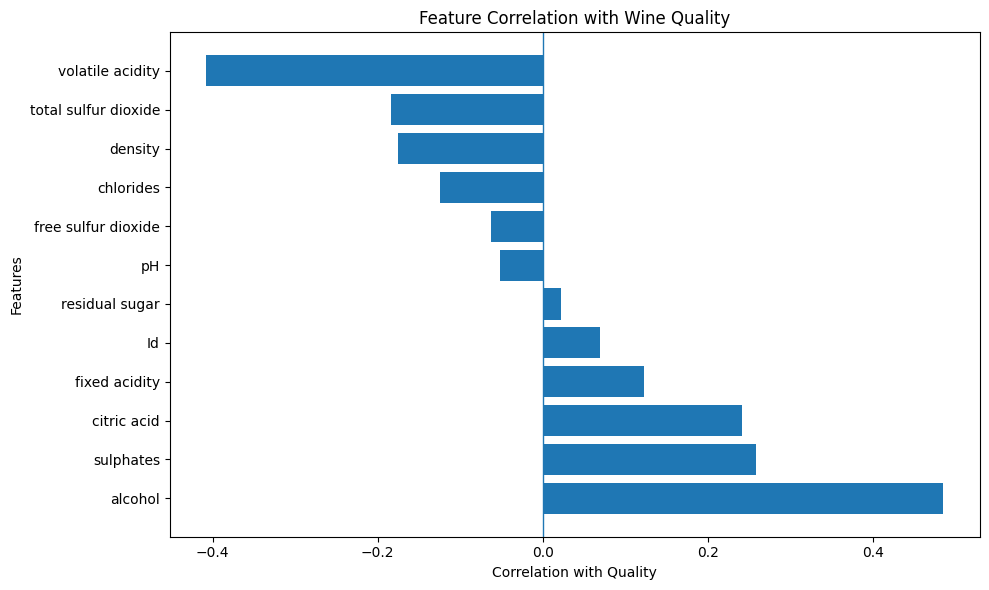

In [49]:
target = "quality"

quality_corr = corr_matrix[target].sort_values(
    ascending=False
)

print("\nCorrelation with Quality:")
print(quality_corr)
feature_corr = quality_corr.drop(target)

plt.figure(figsize=(10, 6))

plt.barh(
    feature_corr.index,
    feature_corr.values
)

plt.xlabel("Correlation with Quality")
plt.ylabel("Features")
plt.title("Feature Correlation with Wine Quality")

plt.axvline(
    x=0,
    linewidth=1
)

plt.tight_layout()
plt.show()



In [50]:
##Dropping residual sugar as its correlation with quality is very less
df = df.drop(["residual sugar","Id"], axis=1)


In [51]:
df

,fixed acidity,volatile acidity,citric acid,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...
1138,6.3,0.510,0.13,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1139,6.8,0.620,0.08,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6
1140,6.2,0.600,0.08,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1141,5.9,0.550,0.10,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6


In [52]:
X = df.drop("quality", axis=1).values

y = df["quality"]
Y=df["quality"].values

print("X shape:", X.shape)
print("y shape:", y.shape)

X_mean = np.mean(X, axis=0)
X_std = np.std(X, axis=0)
X_std[X_std == 0] = 1.0 # Prevent division by zero
X_scaled = (X - X_mean) / X_std
y_std = np.std(y)

X shape: (1143, 10)
y shape: (1143,)


In [53]:
#Training and test split

In [54]:
np.random.seed(42)

m = X.shape[0]

indices = np.random.permutation(m)

train_size = int(0.8 * m)

train_indices = indices[:train_size]
test_indices = indices[train_size:]

X_train = X[train_indices]
X_test = X[test_indices]

y_train = y[train_indices]
y_test = y[test_indices]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (914, 10)
X_test shape: (229, 10)
y_train shape: (914,)
y_test shape: (229,)


In [55]:
mu = np.mean(X_train, axis=0)
sigma = np.std(X_train, axis=0)

X_train_norm = (X_train - mu) / sigma
X_test_norm = (X_test - mu) / sigma

In [56]:
n = X_train_norm.shape[1]

w = np.zeros(n)
b = 0

print("w =", w)
print("b =", b)

w = [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
b = 0


In [57]:
def compute_model_output(X, w, b):
    predictions = np.dot(X, w) + b
    return predictions

def compute_cost(X, y, w, b):
    m = X.shape[0]
    predictions = compute_model_output(X, w, b)
    errors = predictions - y
    cost = (1 / (2 * m)) * np.sum(errors ** 2)
    return cost

def compute_gradient(X, y, w, b):
    m = X.shape[0]
    predictions = compute_model_output(X, w, b)
    errors = predictions - y
    dj_dw = (1 / m) * np.dot(X.T, errors)
    dj_db = (1 / m) * np.sum(errors)
    return dj_dw, dj_db

    dj_dw, dj_db = compute_gradient(
    X_train_norm,
    y_train,
    w,
    b
)

    
def gradient_descent(X, y, w, b, alpha, num_iters):
    J_history = []
    for i in range(num_iters):
        # Calculate gradient
        dj_dw, dj_db = compute_gradient(
            X,
            y,
            w,
            b
        )

        # Update parameters
        w = w - alpha * dj_dw
        b = b - alpha * dj_db
        # Save cost
        cost = compute_cost(
            X,
            y,
            w,
            b
        )

        J_history.append(cost)
    return w, b, J_history    

In [58]:
w_init = np.zeros(X_train_norm.shape[1])
b_init = 0

alpha = 0.01
num_iters = 2000

In [59]:
w_final, b_final, J_history = gradient_descent(
    X_train_norm,
    y_train,
    w_init,
    b_init,
    alpha,
    num_iters
)

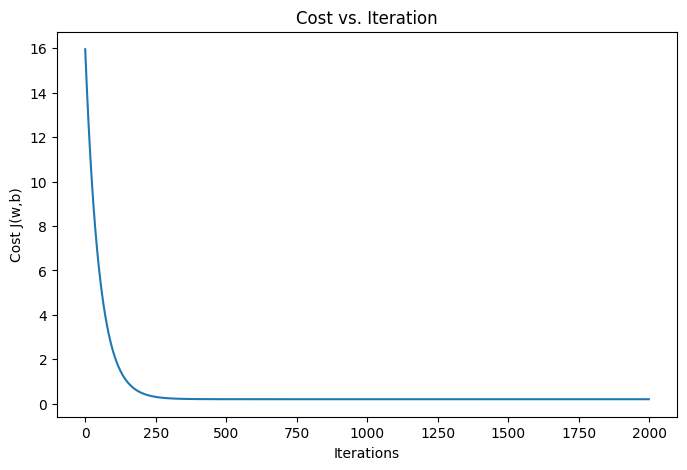

In [60]:
plt.figure(figsize=(8, 5))

plt.plot(J_history)

plt.xlabel("Iterations")
plt.ylabel("Cost J(w,b)")
plt.title("Cost vs. Iteration")

plt.show()

In [61]:
y_train_pred = compute_model_output(
    X_train_norm,
    w_final,
    b_final
)

y_test_pred = compute_model_output(
    X_test_norm,
    w_final,
    b_final
)

In [62]:
train_rmse = np.sqrt(
    np.mean((y_train_pred - y_train) ** 2)
)

test_rmse = np.sqrt(
    np.mean((y_test_pred - y_test) ** 2)
)

print("Training RMSE:", train_rmse)
print("Test RMSE:", test_rmse)

Training RMSE: 0.6434298302297153
Test RMSE: 0.6150059267790203


In [63]:
def compute_r2(y, predictions):

    ss_res = np.sum((y - predictions) ** 2)

    ss_tot = np.sum((y - np.mean(y)) ** 2)

    r2 = 1 - (ss_res / ss_tot)

    return r2

In [64]:
train_r2 = compute_r2(
    y_train,
    y_train_pred
)

test_r2 = compute_r2(
    y_test,
    y_test_pred
)

print("Training R²:", train_r2)
print("Test R²:", test_r2)

Training R²: 0.3764604400144794
Test R²: 0.35462746409543267


In [65]:
def regression_accuracy(y_true, y_pred, tolerance):

    correct = np.abs(y_true - y_pred) <= tolerance

    return np.mean(correct)

In [66]:
y_train_pred = compute_model_output(
    X_train_norm,
    w_final,
    b_final
)

y_test_pred = compute_model_output(
    X_test_norm,
    w_final,
    b_final
)

In [67]:
y_std = np.std(y_train)

print("Training target standard deviation:", y_std)

Training target standard deviation: 0.8148340810401301


In [68]:
tolerance = 2 * y_std

train_acc = regression_accuracy(
    y_train,
    y_train_pred,
    tolerance
)

test_acc = regression_accuracy(
    y_test,
    y_test_pred,
    tolerance
)

print("Tolerance:", tolerance)

print("Train Accuracy:", train_acc)

print("Test Accuracy:", test_acc)

Tolerance: 1.6296681620802602
Train Accuracy: 0.9748358862144421
Test Accuracy: 0.9956331877729258
